In [91]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ta.momentum import RSIIndicator
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [93]:
stock_list = {
    "Apple": "AAPL",
    "Tesla": "TSLA",
    "Google": "GOOGL",
    "Microsoft": "MSFT",
    "Amazon": "AMZN",
    "Reliance": "RELIANCE.NS",
    "TCS": "TCS.NS"
}

stock_name = "Apple"
ticker = stock_list[stock_name]

In [123]:
df = yf.download(ticker, start="2015-01-01", end="2024-12-31")

# If MultiIndex exists → remove second level
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Now select Close properly
df = df[['Close']].copy()

df.dropna(inplace=True)

print(type(df['Close']))
print(df['Close'].shape)


[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.series.Series'>
(2515,)


In [125]:
df['MA100'] = df['Close'].rolling(100).mean()
df['MA200'] = df['Close'].rolling(200).mean()

In [127]:
df['Close'] = df['Close'].squeeze()

rsi = RSIIndicator(close=df['Close'], window=14)
df['RSI'] = rsi.rsi()

In [129]:
df['Signal'] = 0
df.loc[df['MA100'] > df['MA200'], 'Signal'] = 1   # Buy
df.loc[df['MA100'] < df['MA200'], 'Signal'] = -1  # Sell

In [131]:
df['RSI_Signal'] = 0
df.loc[df['RSI'] < 30, 'RSI_Signal'] = 1   # Buy
df.loc[df['RSI'] > 70, 'RSI_Signal'] = -1  # Sell


In [133]:
df['Final_Signal'] = df['Signal'] + df['RSI_Signal']
df['Final_Signal'] = df['Final_Signal'].apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))


In [135]:
df['Target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)
df.dropna(inplace=True)


In [137]:
X = df[['MA100', 'MA200', 'RSI']]
y = df['Target']


In [139]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


In [141]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)


RandomForestClassifier()

In [143]:
pred = model.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print("Model Accuracy:", accuracy)


Model Accuracy: 0.4504310344827586


In [145]:
latest_data = df[['MA100', 'MA200', 'RSI']].iloc[-1:]
prediction = model.predict(latest_data)

if prediction[0] == 1:
    print("ML Prediction: Stock likely to go UP tomorrow")
else:
    print("ML Prediction: Stock likely to go DOWN tomorrow")


ML Prediction: Stock likely to go DOWN tomorrow


In [147]:
latest_signal = df['Final_Signal'].iloc[-1]

if latest_signal == 1 and prediction[0] == 1:
    print("FINAL DECISION: STRONG BUY")
elif latest_signal == -1 and prediction[0] == 0:
    print("FINAL DECISION: STRONG SELL")
else:
    print("FINAL DECISION: HOLD / WAIT")


FINAL DECISION: HOLD / WAIT


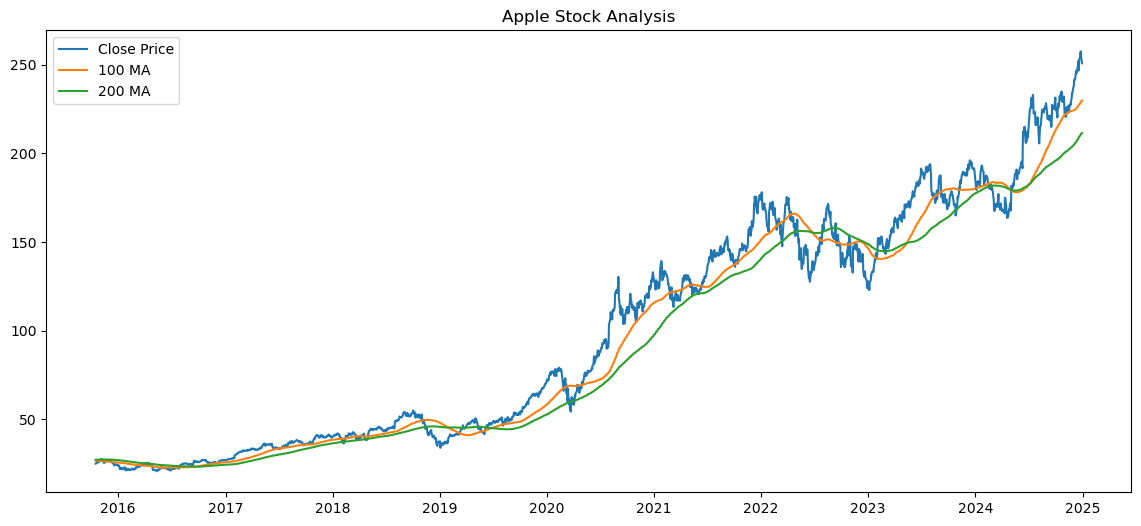

In [149]:
plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA100'], label='100 MA')
plt.plot(df['MA200'], label='200 MA')
plt.legend()
plt.title(f"{stock_name} Stock Analysis")
plt.show()


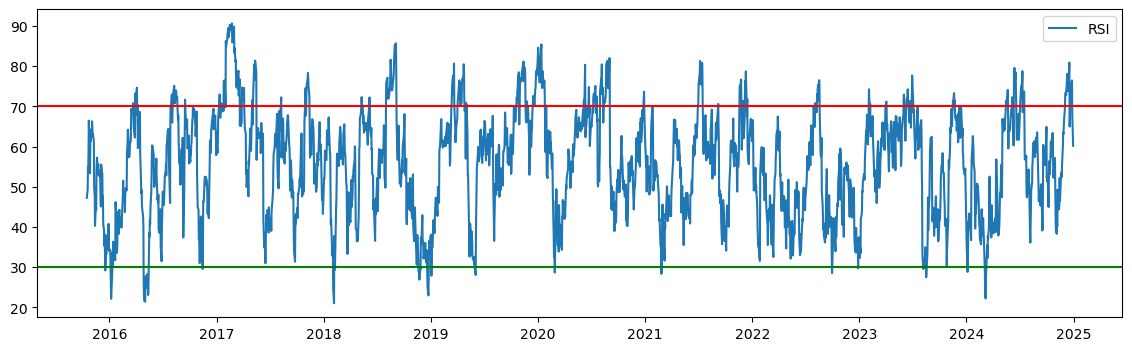

In [151]:
plt.figure(figsize=(14,4))
plt.plot(df['RSI'], label='RSI')
plt.axhline(30, color='green')
plt.axhline(70, color='red')
plt.legend()
plt.show()


In [155]:
pip install streamlit yfinance ta scikit-learn plotly

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [1]:
import streamlit as st

In [ ]:
!streamlit run stock_prediction_app.py

In [ ]:
from sklearn.